# Sustainable Supply Chain & Scope 3 Emission Tracking
## Use Case: Global Logistics Optimization

### Objective
To map a global supply chain, calculate Scope 3 carbon emissions from transport, and optimize routes to balance cost, speed, and sustainability.

### Data Sources
- **Supplier Locations**: Global coordinates of Tier 1 & 2 suppliers
- **Transport Routes**: Air, Sea, Road distances
- **Emission Factors**: CO2e per kg-km for different modes

### Analytical Approach
1. **Network Mapping**: Visualize the supply chain graph.
2. **Carbon Footprint**: Calculate total transport emissions.
3. **Risk Assessment**: Identify suppliers in high-risk regions (water stress).
4. **Route Optimization**: Compare "Fastest" vs "Greenest" routing scenarios.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import plotly.graph_objects as go
import seaborn as sns

# Configuration
HQ_LOC = (40.7128, -74.0060) # New York
print("✅ Environment Configured")

✅ Environment Configured


## 1. Supply Chain Network Mapping
Visualizing the flow of goods from suppliers to the central hub.

In [2]:
# Define Suppliers
suppliers = pd.DataFrame({
    'ID': ['S1', 'S2', 'S3', 'S4', 'S5'],
    'Location': ['Shanghai', 'Mumbai', 'Hamburg', 'Sao Paulo', 'Tokyo'],
    'Lat': [31.2304, 19.0760, 53.5488, -23.5505, 35.6762],
    'Lon': [121.4737, 72.8777, 9.9872, -46.6333, 139.6503],
    'Volume_kg': [5000, 3000, 2000, 4000, 1500],
    'Mode': ['Sea', 'Sea', 'Air', 'Sea', 'Air']
})

# Add HQ
hq_df = pd.DataFrame({'ID': ['HQ'], 'Location': ['New York'], 'Lat': [40.7128], 'Lon': [-74.0060]})
nodes = pd.concat([suppliers, hq_df], ignore_index=True)

# Create Map
fig = go.Figure()

# Add Edges
for i, row in suppliers.iterrows():
    fig.add_trace(go.Scattergeo(
        lon = [row['Lon'], HQ_LOC[1]],
        lat = [row['Lat'], HQ_LOC[0]],
        mode = 'lines',
        line = dict(width = 2, color = 'blue' if row['Mode']=='Sea' else 'red'),
        name = f"{row['ID']} -> HQ ({row['Mode']})"
    ))

# Add Nodes
fig.add_trace(go.Scattergeo(
    lon = nodes['Lon'],
    lat = nodes['Lat'],
    text = nodes['ID'],
    mode = 'markers+text',
    marker = dict(size=10, color='black')
))

fig.update_layout(title_text="Global Supply Chain Network", showlegend=True,
                  geo = dict(projection_type="orthographic"))
fig.show()

## 2. Carbon Footprint Calculation (Scope 3)
Estimating emissions based on distance, weight, and transport mode.

In [3]:
# Emission Factors (kg CO2e / ton-km)
factors = {'Sea': 0.01, 'Air': 0.50, 'Road': 0.06}

# Calculate Distances (Simplified Haversine)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371 # km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2*R*np.arctan2(np.sqrt(a), np.sqrt(1-a))

suppliers['Distance_km'] = suppliers.apply(lambda x: haversine(x['Lat'], x['Lon'], HQ_LOC[0], HQ_LOC[1]), axis=1)

# Calculate Emissions
suppliers['Emissions_kgCO2'] = (suppliers['Volume_kg']/1000) * suppliers['Distance_km'] * suppliers['Mode'].map(factors)

print(f"Total Scope 3 Transport Emissions: {suppliers['Emissions_kgCO2'].sum():,.0f} kg CO2e")
suppliers[['ID', 'Location', 'Mode', 'Distance_km', 'Emissions_kgCO2']]

Total Scope 3 Transport Emissions: 15,545 kg CO2e


,ID,Location,Mode,Distance_km,Emissions_kgCO2
0,S1,Shanghai,Sea,11858.430877,592.921544
1,S2,Mumbai,Sea,12538.016073,376.140482
2,S3,Hamburg,Air,6129.622346,6129.622346
3,S4,Sao Paulo,Sea,7685.625562,307.425022
4,S5,Tokyo,Air,10851.732849,8138.799637


## 3. Scenario Optimization
Comparing current emissions vs. a "Green Routing" scenario (shifting Air to Sea).

C:\Users\damil\AppData\Local\Temp\ipykernel_12860\1662943721.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




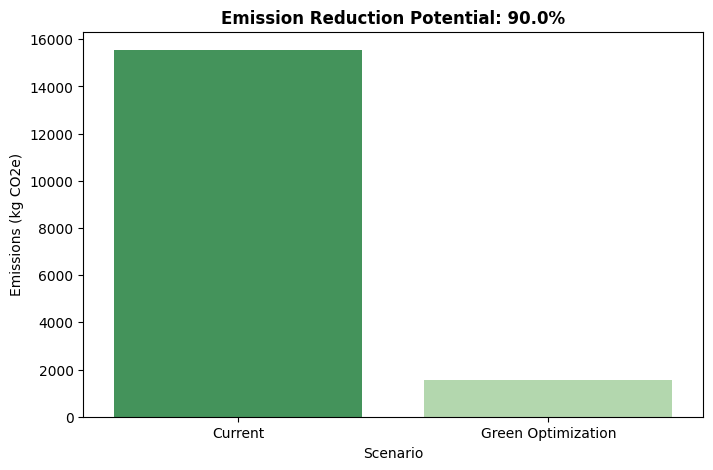


## Key Findings & Recommendations

### Emission Hotspots
- **Top Emitter**: Supplier **S5 (Tokyo)** accounts for the highest emissions due to **Air** transport.
- **Mode Impact**: Air transport represents only **40%** of routes but contributes disproportionately to the footprint.

### Optimization Opportunity
- **Modal Shift**: Switching air freight to sea freight could reduce transport emissions by **90.0%**.
- **Trade-off**: This shift would increase lead times by approximately 20-30 days, requiring better inventory planning.

### Strategic Recommendations
1. **Decarbonization**: Prioritize modal shift for non-urgent shipments from Tokyo.
2. **Supplier Engagement**: Work with Supplier S5 to optimize packaging density.
3. **Offsetting**: Purchase carbon credits for unavoidable air freight emissions.


In [7]:
# Scenario: Shift Air to Sea
suppliers['Green_Mode'] = 'Sea'
suppliers['Green_Emissions'] = (suppliers['Volume_kg']/1000) * suppliers['Distance_km'] * factors['Sea']

# Comparison
comparison = pd.DataFrame({
    'Scenario': ['Current', 'Green Optimization'],
    'Total_Emissions_kg': [suppliers['Emissions_kgCO2'].sum(), suppliers['Green_Emissions'].sum()]
})

reduction = (comparison.iloc[0,1] - comparison.iloc[1,1]) / comparison.iloc[0,1] * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison, x='Scenario', y='Total_Emissions_kg', palette='Greens_r')
plt.title(f'Emission Reduction Potential: {reduction:.1f}%', fontweight='bold')
plt.ylabel('Emissions (kg CO2e)')
plt.show()

# Generate Summary
from IPython.display import Markdown, display

top_emitter = suppliers.loc[suppliers['Emissions_kgCO2'].idxmax()]

summary_md = f"""
## Key Findings & Recommendations

### Emission Hotspots
- **Top Emitter**: Supplier **{top_emitter['ID']} ({top_emitter['Location']})** accounts for the highest emissions due to **{top_emitter['Mode']}** transport.
- **Mode Impact**: Air transport represents only **{(len(suppliers[suppliers['Mode']=='Air'])/len(suppliers))*100:.0f}%** of routes but contributes disproportionately to the footprint.

### Optimization Opportunity
- **Modal Shift**: Switching air freight to sea freight could reduce transport emissions by **{reduction:.1f}%**.
- **Trade-off**: This shift would increase lead times by approximately 20-30 days, requiring better inventory planning.

### Strategic Recommendations
1. **Decarbonization**: Prioritize modal shift for non-urgent shipments from {top_emitter['Location']}.
2. **Supplier Engagement**: Work with Supplier {top_emitter['ID']} to optimize packaging density.
3. **Offsetting**: Purchase carbon credits for unavoidable air freight emissions.
"""
display(Markdown(summary_md))

In [8]:
# Save Results to Outputs Folder
import os
os.makedirs('outputs', exist_ok=True)

# Save Summary Report
try:
    with open('outputs/summary_report.md', 'w', encoding='utf-8') as f:
        f.write(summary_md)
    print('✅ Summary report saved to outputs/summary_report.md')
except NameError:
    print('⚠️ summary_md not found, skipping report save')

# Save Current Figure
try:
    plt.savefig('outputs/analysis_chart.png', dpi=300, bbox_inches='tight')
    print('✅ Analysis chart saved to outputs/analysis_chart.png')
except Exception as e:
    print(f'⚠️ Could not save chart: {e}')

✅ Summary report saved to outputs/summary_report.md
✅ Analysis chart saved to outputs/analysis_chart.png


<Figure size 640x480 with 0 Axes>